In [14]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('customer_data.csv')
df.head()

In [20]:
print(df.info())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [28]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

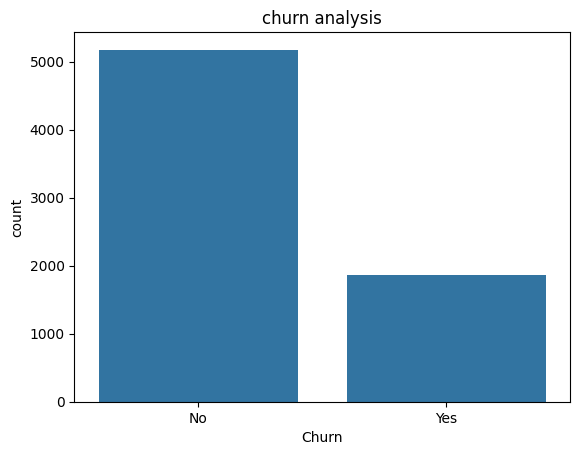

In [27]:
df['Churn'].value_counts()
sns.countplot(x='Churn',data=df)
plt.title('churn analysis')
plt.show()

In [46]:
# Identify categorical and numerical features
categorical_features=df.select_dtypes(include='object').columns.tolist()
numerical_features=df.select_dtypes(include=['int64','float64']).columns.tolist()

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    if 'customerID' in categorical_features:
        categorical_features.remove('customerID')
    print("\n'customerID' column removed.")
else:
    print("\n'customerID' column not found.")


print('categorical_features:',categorical_features)
print('numerical_features:',numerical_features)


'customerID' column not found.
categorical_features: []
numerical_features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


In [49]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
label_encoder=LabelEncoder()
for col in ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling',
            'PaymentMethod', 'Churn', 'gender']:
    if col in df.columns:
        df[col]=label_encoder.fit_transform(df[col])
# One hot encode 
df = pd.get_dummies(df, columns=[col for col in categorical_features if col not in ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling',
            'PaymentMethod', 'Churn', 'gender']], drop_first=True)

print("\nProcessed dataset information after encoding:")
df.info()


Processed dataset information after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6554 entries, gender to Tenure_Group_60+ Months
dtypes: bool(6535), float64(1), int64(18)
memory usage: 44.9 MB


In [51]:
# standard scalar
numerical_features=[col for col in numerical_features if col!='Churn']
scalar=StandardScaler()
df[numerical_features] = scalar.fit_transform(df[numerical_features])
print("\nProcessed dataset information after scaling:")
df.info()
print("\nFirst 5 rows of the scaled data:")
print(df.head())


Processed dataset information after scaling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6554 entries, gender to Tenure_Group_60+ Months
dtypes: bool(6535), float64(18), int64(1)
memory usage: 44.9 MB

First 5 rows of the scaled data:
     gender  SeniorCitizen   Partner  Dependents    tenure  PhoneService  \
0 -1.009559      -0.439916  1.034530   -0.654012 -1.277445     -3.054010   
1  0.990532      -0.439916 -0.966622   -0.654012  0.066327      0.327438   
2  0.990532      -0.439916 -0.966622   -0.654012 -1.236724      0.327438   
3  0.990532      -0.439916 -0.966622   -0.654012  0.514251     -3.054010   
4 -1.009559      -0.439916 -0.966622   -0.654012 -1.236724      0.327438   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0       0.062723        -1.183234       -0.918838      1.242550  ...   
1      -0.991588        -1.183234        1.407321     -1.029919  ...   
2      -0.991588        -1.183234        1.407321   

In [41]:
bins = [0, 12, 24, 36, 48, 60, np.inf]
labels = ['0-12 Months', '13-24 Months', '25-36 Months', '37-48 Months', '49-60 Months', '60+ Months']
if 'tenure' in df.columns:
    df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)
    df = pd.get_dummies(df, columns=['Tenure_Group'], drop_first=True)
    print("\n'Tenure_Group' feature created and one-hot encoded.")
else:
    print("\n'tenure' column not found, skipping 'Tenure_Group' feature engineering.")

print("\nDataset information after optional feature engineering:")
df.info()
print("\nFirst 5 rows after optional feature engineering:")
print(df.head())


'Tenure_Group' feature created and one-hot encoded.

Dataset information after optional feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6554 entries, gender to Tenure_Group_60+ Months
dtypes: bool(6535), float64(1), int64(18)
memory usage: 44.9 MB

First 5 rows after optional feature engineering:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             0  ...   
2 

In [ ]:
# Feature Engineering
